In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

GPU Available: True
Device: NVIDIA A100-SXM4-40GB MIG 2g.10gb


In [2]:
import zipfile

with zipfile.ZipFile("slices.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [3]:
import os
os.remove("slices.zip")

In [27]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms.functional as TF
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────────────────────
CFG = {
    'data_dir': './dataset/slices',
    'checkpoint_dir': './checkpoints',  

    # Model
    'num_classes': 5,
    'in_channels': 1,
    'base_features': 32,

    # Training
    'img_size': 256,
    'batch_size': 8,
    'num_epochs': 10,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'val_split': 0.15,
    'seed': 42,

    # Loss
    'dice_weight': 0.6,
    'bce_weight': 0.4,

    # Misc
    'num_workers': 4,
    'pin_memory': True,
    'use_amp': True,
    'organ_names': ['Liver', 'Spleen', 'Left Kidney', 'Right Kidney', 'Pancreas'],
}

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM   : {total:.1f} GB')

os.makedirs(CFG['checkpoint_dir'], exist_ok=True)

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB MIG 2g.10gb
VRAM   : 10.5 GB


In [28]:
class CTSegDataset(Dataset):
    """
    Expects:
      image_dir/  — *.npy files, each shape (H, W), HU values
      mask_dir/   — *.npy files, each shape (5, H, W), binary {0,1}
    File stems must match between image_dir and mask_dir.
    """
    def __init__(self, image_paths, mask_paths, img_size=256, augment=False):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.img_size    = img_size
        self.augment     = augment

    def __len__(self):
        return len(self.image_paths)

    def _normalize_ct(self, img: np.ndarray) -> np.ndarray:
        """Clip to soft-tissue window then min-max normalize to [0,1]."""
        img = np.clip(img, -175, 250)   # HU window: abdomen soft tissue
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img.astype(np.float32)

    def _augment(self, image: torch.Tensor, mask: torch.Tensor):
        """Joint augmentation — same random transform applied to image AND mask."""
        # Random horizontal flip
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)

        # Random vertical flip
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask  = TF.vflip(mask)

        # Random rotation ±15°
        if random.random() > 0.5:
            angle = random.uniform(-15, 15)
            image = TF.rotate(image, angle)
            mask  = TF.rotate(mask,  angle)

        # Random brightness / contrast (image only)
        if random.random() > 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
            image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))

        return image, mask

    def __getitem__(self, idx):
        image = np.load(self.image_paths[idx])  # (H, W)
        mask  = np.load(self.mask_paths[idx])   # (5, H, W)

        image = self._normalize_ct(image)
        mask  = (mask > 0.5).astype(np.float32)

        # → tensors
        image = torch.from_numpy(image).unsqueeze(0)  # (1, H, W)
        mask  = torch.from_numpy(mask)                # (5, H, W)

        # Resize
        s = self.img_size
        image = F.interpolate(image.unsqueeze(0), (s, s), mode='bilinear',  align_corners=False).squeeze(0)
        mask  = F.interpolate(mask.unsqueeze(0),  (s, s), mode='nearest').squeeze(0)

        if self.augment:
            image, mask = self._augment(image, mask)

        return image, mask


def build_loaders(cfg):
    folder = Path(cfg['data_dir'])

    ct_files = sorted(folder.glob('*_ct.npy'))
    mask_files = sorted(folder.glob('*_mask.npy'))

    assert len(ct_files) == len(mask_files) > 0, "Dataset mismatch!"

    n = len(ct_files)
    n_val = int(n * cfg['val_split'])

    indices = list(range(n))
    random.shuffle(indices)

    val_idx = indices[:n_val]
    trn_idx = indices[n_val:]

    trn_imgs = [ct_files[i] for i in trn_idx]
    trn_masks = [mask_files[i] for i in trn_idx]

    val_imgs = [ct_files[i] for i in val_idx]
    val_masks = [mask_files[i] for i in val_idx]

    trn_ds = CTSegDataset(trn_imgs, trn_masks, cfg['img_size'], augment=True)
    val_ds = CTSegDataset(val_imgs, val_masks, cfg['img_size'], augment=False)

    trn_loader = DataLoader(trn_ds, batch_size=cfg['batch_size'], shuffle=True,
                           num_workers=cfg['num_workers'], pin_memory=cfg['pin_memory'],
                           drop_last=True)

    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=cfg['pin_memory'])

    print(f"Train: {len(trn_ds)} | Val: {len(val_ds)}")

    return trn_loader, val_loader


# ── Sanity check (runs without actual data files) ─────────────────────────────
# trn_loader, val_loader = build_loaders(CFG)
print('Dataset class ready — call build_loaders(CFG) once your data paths are set.')

Dataset class ready — call build_loaders(CFG) once your data paths are set.


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Building Blocks
# ─────────────────────────────────────────────────────────────────────────────

class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2  — the core U-Net block."""
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        mid_ch = mid_ch or out_ch
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Soft attention gate from Oktay et al. (2018).
    Learns *where* to focus on the skip-connection features.
    g  = gating signal from decoder (coarser)
    x  = skip connection from encoder (finer)
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

    def forward(self, g, x):
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        # upsample g to match x spatial size
        g1  = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        psi = self.psi(F.relu(g1 + x1, inplace=True))
        return x * psi   # attended skip features


# ─────────────────────────────────────────────────────────────────────────────
# Attention U-Net
# ─────────────────────────────────────────────────────────────────────────────

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=5, base_features=32):
        super().__init__()
        f = base_features   # 32, 64, 128, 256, 512

        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc1 = DoubleConv(in_channels, f)
        self.enc2 = DoubleConv(f,     f*2)
        self.enc3 = DoubleConv(f*2,   f*4)
        self.enc4 = DoubleConv(f*4,   f*8)
        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.bottleneck = DoubleConv(f*8, f*16)

        # ── Decoder (with attention gates) ───────────────────────────────────
        self.att4 = AttentionGate(F_g=f*16, F_l=f*8,  F_int=f*8)
        self.up4  = nn.ConvTranspose2d(f*16, f*8, 2, stride=2)
        self.dec4 = DoubleConv(f*16, f*8)

        self.att3 = AttentionGate(F_g=f*8,  F_l=f*4,  F_int=f*4)
        self.up3  = nn.ConvTranspose2d(f*8,  f*4, 2, stride=2)
        self.dec3 = DoubleConv(f*8,  f*4)

        self.att2 = AttentionGate(F_g=f*4,  F_l=f*2,  F_int=f*2)
        self.up2  = nn.ConvTranspose2d(f*4,  f*2, 2, stride=2)
        self.dec2 = DoubleConv(f*4,  f*2)

        self.att1 = AttentionGate(F_g=f*2,  F_l=f,    F_int=f)
        self.up1  = nn.ConvTranspose2d(f*2,  f,   2, stride=2)
        self.dec1 = DoubleConv(f*2,  f)

        # ── Output ───────────────────────────────────────────────────────────
        self.out_conv = nn.Conv2d(f, num_classes, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)              # (B, f,   H,   W)
        s2 = self.enc2(self.pool(s1))  # (B, f*2, H/2, W/2)
        s3 = self.enc3(self.pool(s2))  # (B, f*4, H/4, W/4)
        s4 = self.enc4(self.pool(s3))  # (B, f*8, H/8, W/8)

        # Bottleneck
        b  = self.bottleneck(self.pool(s4))  # (B, f*16, H/16, W/16)

        # Decoder with attention
        d4 = self.dec4(torch.cat([self.att4(b,  s4), self.up4(b)],  dim=1))
        d3 = self.dec3(torch.cat([self.att3(d4, s3), self.up3(d4)], dim=1))
        d2 = self.dec2(torch.cat([self.att2(d3, s2), self.up2(d3)], dim=1))
        d1 = self.dec1(torch.cat([self.att1(d2, s1), self.up1(d2)], dim=1))

        return self.out_conv(d1)  # (B, num_classes, H, W) — raw logits


# ── Quick parameter count ─────────────────────────────────────────────────────
model = AttentionUNet(
    in_channels   = CFG['in_channels'],
    num_classes   = CFG['num_classes'],
    base_features = CFG['base_features'],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters : {total_params:,}   ({total_params/1e6:.1f} M)')

# Estimate VRAM for one batch (fp16)
dummy = torch.randn(CFG['batch_size'], 1, CFG['img_size'], CFG['img_size']).to(DEVICE)
with torch.no_grad(), autocast():
    out = model(dummy)
print(f'Output shape     : {tuple(out.shape)}')
print(f'Peak VRAM        : {torch.cuda.max_memory_allocated()/1e9:.2f} GB')
del dummy, out
torch.cuda.empty_cache()

Model parameters : 8,027,089   (8.0 M)
Output shape     : (8, 5, 256, 256)
Peak VRAM        : 1.36 GB


In [30]:
class DiceLoss(nn.Module):
    """
    Soft Dice loss — works per-channel then averages.
    Handles class imbalance natively (organs are tiny vs background).
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)        # (B, C, H, W)
        B, C = probs.shape[:2]
        probs   = probs.view(B, C, -1)       # (B, C, N)
        targets = targets.view(B, C, -1)

        intersection = (probs * targets).sum(dim=2)            # (B, C)
        dice = (2 * intersection + self.smooth) / \
               (probs.sum(dim=2) + targets.sum(dim=2) + self.smooth)
        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    """
    Combined Dice + Binary Cross-Entropy loss.
    - Dice: handles class imbalance, directly optimizes the Dice metric
    - BCE:  provides stable gradients at the start of training
    """
    def __init__(self, dice_weight=0.6, bce_weight=0.4):
        super().__init__()
        self.dice     = DiceLoss()
        self.bce      = nn.BCEWithLogitsLoss()
        self.dw       = dice_weight
        self.bw       = bce_weight

    def forward(self, logits, targets):
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


# ── Dice metric (for evaluation — hard predictions) ───────────────────────────
@torch.no_grad()
def dice_score(logits, targets, threshold=0.5, eps=1e-8):
    """
    Returns per-class and mean Dice scores.
    logits  : (B, C, H, W)  — raw model output
    targets : (B, C, H, W)  — binary ground truth
    """
    preds   = (torch.sigmoid(logits) > threshold).float()
    B, C    = preds.shape[:2]
    preds   = preds.view(B, C, -1)
    targets = targets.view(B, C, -1)

    intersection = (preds * targets).sum(dim=2)              # (B, C)
    dice = (2 * intersection + eps) / \
           (preds.sum(dim=2) + targets.sum(dim=2) + eps)
    per_class = dice.mean(dim=0)   # (C,)
    mean_dice = per_class.mean()   # scalar
    return per_class, mean_dice


criterion = CombinedLoss(CFG['dice_weight'], CFG['bce_weight'])
print('Loss function ready.')

Loss function ready.


In [31]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay'],
)

# Cosine annealing — smoothly decays LR over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = CFG['num_epochs'],
    eta_min= 1e-6,
)

# Mixed-precision scaler (fp16 — halves VRAM, 2-3× faster on A100)
scaler = GradScaler(enabled=CFG['use_amp'])

print('Optimizer : AdamW')
print('Scheduler : CosineAnnealingLR')
print(f'AMP       : {CFG["use_amp"]}')

Optimizer : AdamW
Scheduler : CosineAnnealingLR
AMP       : True


In [32]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    per_class_dice = torch.zeros(CFG['num_classes'])

    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
            loss   = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        pc, md = dice_score(logits.detach(), masks)
        per_class_dice += pc.cpu()

        pbar.set_postfix(loss=f'{loss.item():.4f}', dice=f'{md.item():.4f}')

    n = len(loader)
    return total_loss / n, per_class_dice / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    per_class_dice = torch.zeros(CFG['num_classes'])

    pbar = tqdm(loader, desc='  Val  ', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
            loss   = criterion(logits, masks)

        total_loss += loss.item()
        pc, _ = dice_score(logits, masks)
        per_class_dice += pc.cpu()

    n = len(loader)
    return total_loss / n, per_class_dice / n


print('Train / validate functions ready.')

Train / validate functions ready.


In [33]:
# ── Main Training Loop ────────────────────────────────────────────────────────

# ❗ Build loaders (point to your actual data)
trn_loader, val_loader = build_loaders(CFG)

history = {'trn_loss': [], 'val_loss': [], 'trn_dice': [], 'val_dice': []}
best_dice = 0.0
best_ckpt = Path(CFG['checkpoint_dir']) / 'best_model.pth'

print(f'Starting training for {CFG["num_epochs"]} epochs\n')

for epoch in range(1, CFG['num_epochs'] + 1):
    trn_loss, trn_pc = train_one_epoch(model, trn_loader, optimizer, criterion, scaler, DEVICE)
    val_loss, val_pc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    trn_dice = trn_pc.mean().item()
    val_dice = val_pc.mean().item()

    history['trn_loss'].append(trn_loss)
    history['val_loss'].append(val_loss)
    history['trn_dice'].append(trn_dice)
    history['val_dice'].append(val_dice)

    # Save best checkpoint
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save({
            'epoch':      epoch,
            'state_dict': model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'val_dice':   val_dice,
            'cfg':        CFG,
        }, best_ckpt)
        flag = '  ← best'
    else:
        flag = ''

    lr_now = optimizer.param_groups[0]['lr']
    per = '  '.join([f'{CFG["organ_names"][i][0]}.{val_pc[i]:.3f}' for i in range(CFG['num_classes'])])
    print(f'Ep {epoch:03d}/{CFG["num_epochs"]} │ '
          f'trn {trn_loss:.4f}/{trn_dice:.4f} │ '
          f'val {val_loss:.4f}/{val_dice:.4f} │ '
          f'lr {lr_now:.1e} │ [{per}]{flag}')

Train: 9208 | Val: 1624
Starting training for 10 epochs



  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 001/10 │ trn 0.6332/0.2325 │ val 0.5524/0.4681 │ lr 9.8e-05 │ [L.0.697  S.0.305  L.0.493  R.0.306  P.0.539]  ← best


  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 009/10 │ trn 0.1174/0.8808 │ val 0.1045/0.8921 │ lr 3.4e-06 │ [L.0.896  S.0.926  L.0.812  R.0.920  P.0.906]  ← best


  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 010/10 │ trn 0.1069/0.8871 │ val 0.1014/0.8928 │ lr 1.0e-06 │ [L.0.896  S.0.923  L.0.819  R.0.920  P.0.906]  ← best


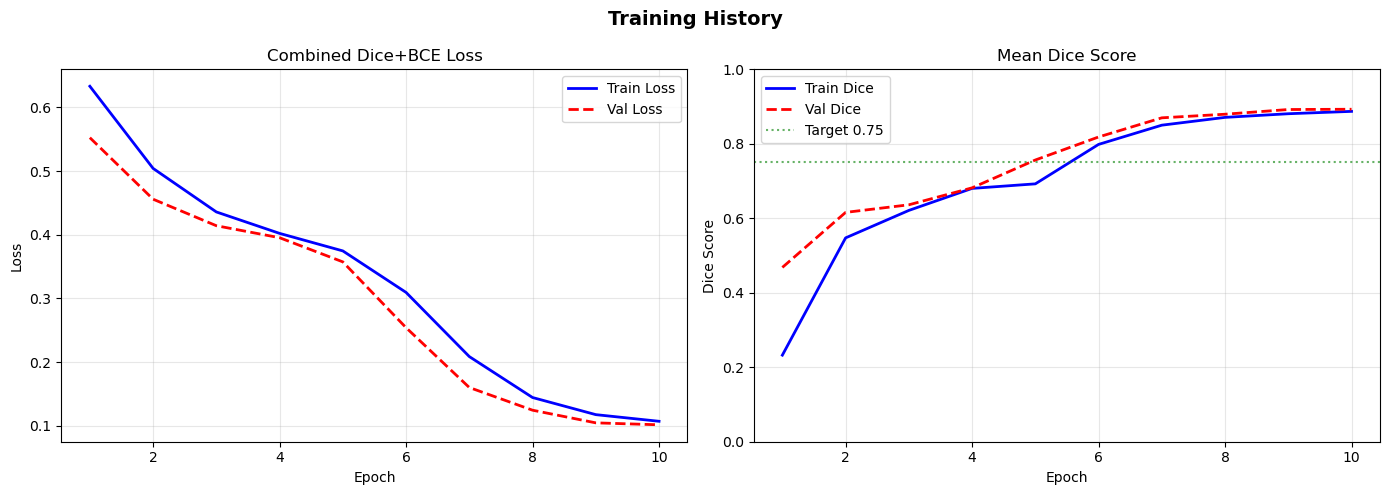

Best Validation Dice : 0.8928


In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

epochs = range(1, len(history['trn_loss']) + 1)

ax1.plot(epochs, history['trn_loss'], 'b-',  label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r--', label='Val Loss',   linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Combined Dice+BCE Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['trn_dice'], 'b-',  label='Train Dice', linewidth=2)
ax2.plot(epochs, history['val_dice'], 'r--', label='Val Dice',   linewidth=2)
ax2.axhline(0.75, color='green', linestyle=':', alpha=0.6, label='Target 0.75')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice Score'); ax2.set_title('Mean Dice Score')
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best Validation Dice : {best_dice:.4f}')

In [35]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['state_dict'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (val_dice={ckpt["val_dice"]:.4f})')

# ── Full validation evaluation ────────────────────────────────────────────────
model.eval()
all_dice = torch.zeros(CFG['num_classes'])
n_batches = 0

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc='Evaluating'):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
        pc, _ = dice_score(logits, masks)
        all_dice += pc.cpu()
        n_batches += 1

all_dice /= n_batches
print('\n── Per-Organ Dice Scores ──────────────────────')
for i, name in enumerate(CFG['organ_names']):
    bar = '█' * int(all_dice[i] * 30)
    print(f'  {name:<15} {all_dice[i]:.4f}  {bar}')
print(f'  {"Mean":<15} {all_dice.mean():.4f}')

Loaded checkpoint from epoch 10 (val_dice=0.8928)


Evaluating:   0%|          | 0/203 [00:00<?, ?it/s]


── Per-Organ Dice Scores ──────────────────────
  Liver           0.8963  ██████████████████████████
  Spleen          0.9229  ███████████████████████████
  Left Kidney     0.8189  ████████████████████████
  Right Kidney    0.9204  ███████████████████████████
  Pancreas        0.9055  ███████████████████████████
  Mean            0.8928


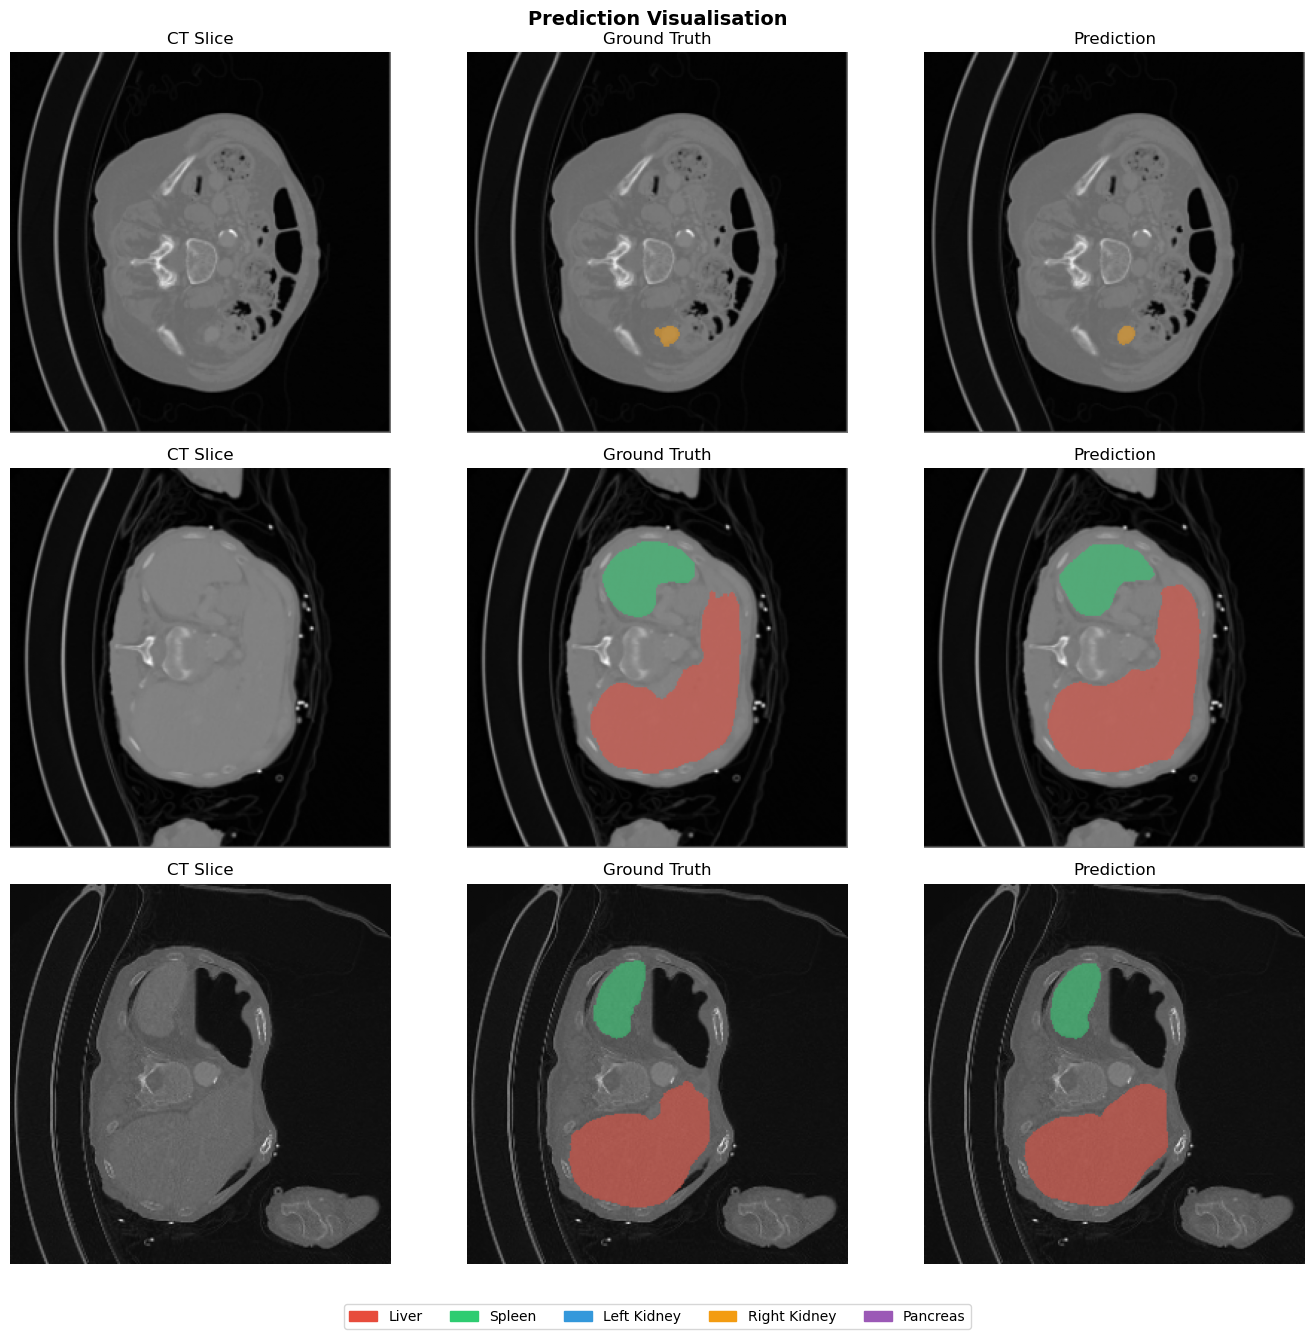

In [36]:
# ── Visual Prediction Check ───────────────────────────────────────────────────
COLORS = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad(), autocast(enabled=CFG['use_amp']):
        logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).cpu().float()

    num_samples = min(num_samples, images.shape[0])
    fig, axes = plt.subplots(num_samples, 3, figsize=(14, 4.5 * num_samples))
    if num_samples == 1: axes = axes[np.newaxis, :]

    for i in range(num_samples):
        img_np = images[i, 0].cpu().numpy()

        # CT image
        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title('CT Slice'); axes[i, 0].axis('off')

        # Ground truth overlay
        axes[i, 1].imshow(img_np, cmap='gray')
        for c in range(CFG['num_classes']):
            mask_c = masks[i, c].numpy()
            rgba = np.zeros((*mask_c.shape, 4))
            r, g, b = tuple(int(COLORS[c][j:j+2], 16)/255 for j in (1,3,5))
            rgba[..., :3] = [r, g, b]
            rgba[..., 3]  = mask_c * 0.55
            axes[i, 1].imshow(rgba)
        axes[i, 1].set_title('Ground Truth'); axes[i, 1].axis('off')

        # Prediction overlay
        axes[i, 2].imshow(img_np, cmap='gray')
        for c in range(CFG['num_classes']):
            pred_c = preds[i, c].numpy()
            rgba = np.zeros((*pred_c.shape, 4))
            r, g, b = tuple(int(COLORS[c][j:j+2], 16)/255 for j in (1,3,5))
            rgba[..., :3] = [r, g, b]
            rgba[..., 3]  = pred_c * 0.55
            axes[i, 2].imshow(rgba)
        axes[i, 2].set_title('Prediction'); axes[i, 2].axis('off')

    patches = [mpatches.Patch(color=COLORS[c], label=CFG['organ_names'][c])
               for c in range(CFG['num_classes'])]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10, framealpha=0.8)
    plt.suptitle('Prediction Visualisation', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, val_loader, DEVICE)